# Heart Failure Prediction — Exploratory Data Analysis

**Dataset:** [Heart Failure Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data)  
**Task:** Perform a comprehensive exploratory data analysis covering univariate, bivariate/multivariate analysis, and predictive-power identification for the `HeartDisease` target variable.

In [1]:
%pip install -q pandas numpy scipy matplotlib seaborn plotly scikit-learn umap-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from scipy.stats import (
    chi2_contingency, mannwhitneyu, ttest_ind,
    pointbiserialr, kruskal, shapiro
)
from scipy.spatial.distance import pdist, squareform

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.preprocessing import StandardScaler, LabelEncoder
import umap

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

## 0. Data Loading & Overview

In [3]:
URL = "https://raw.githubusercontent.com/benbobyabraham/heart_failure_prediction_dataset_kaggle/main/heart.csv"
df = pd.read_csv(URL)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
target = "HeartDisease"

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Target column:", target)
print()
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Target column: HeartDisease

Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.describe(include="object")

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


## 1. Univariate Analysis

### 1a. Numerical Variables — Descriptive Statistics

In [8]:
desc_stats = pd.DataFrame(index=num_cols)
desc_stats["Mean"]     = df[num_cols].mean()
desc_stats["Median"]   = df[num_cols].median()
desc_stats["Mode"]     = df[num_cols].mode().iloc[0]
desc_stats["Std"]      = df[num_cols].std()
desc_stats["Variance"] = df[num_cols].var()
desc_stats["Min"]      = df[num_cols].min()
desc_stats["Max"]      = df[num_cols].max()
desc_stats["Range"]    = desc_stats["Max"] - desc_stats["Min"]
desc_stats["IQR"]      = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
desc_stats["Skewness"] = df[num_cols].skew()
desc_stats["Kurtosis"] = df[num_cols].kurtosis()

desc_stats.round(3)

,Mean,Median,Mode,Std,Variance,Min,Max,Range,IQR,Skewness,Kurtosis
Age,53.511,54.0,54.0,9.433,88.974,28.0,77.0,49.0,13.00,-0.196,-0.386
RestingBP,132.397,130.0,120.0,18.514,342.774,0.0,200.0,200.0,20.00,0.180,3.271
Cholesterol,198.800,223.0,0.0,109.384,11964.891,0.0,603.0,603.0,93.75,-0.610,0.118
MaxHR,136.809,138.0,150.0,25.460,648.229,60.0,202.0,142.0,36.00,-0.144,-0.448
Oldpeak,0.887,0.6,0.0,1.067,1.138,-2.6,6.2,8.8,1.50,1.023,1.203


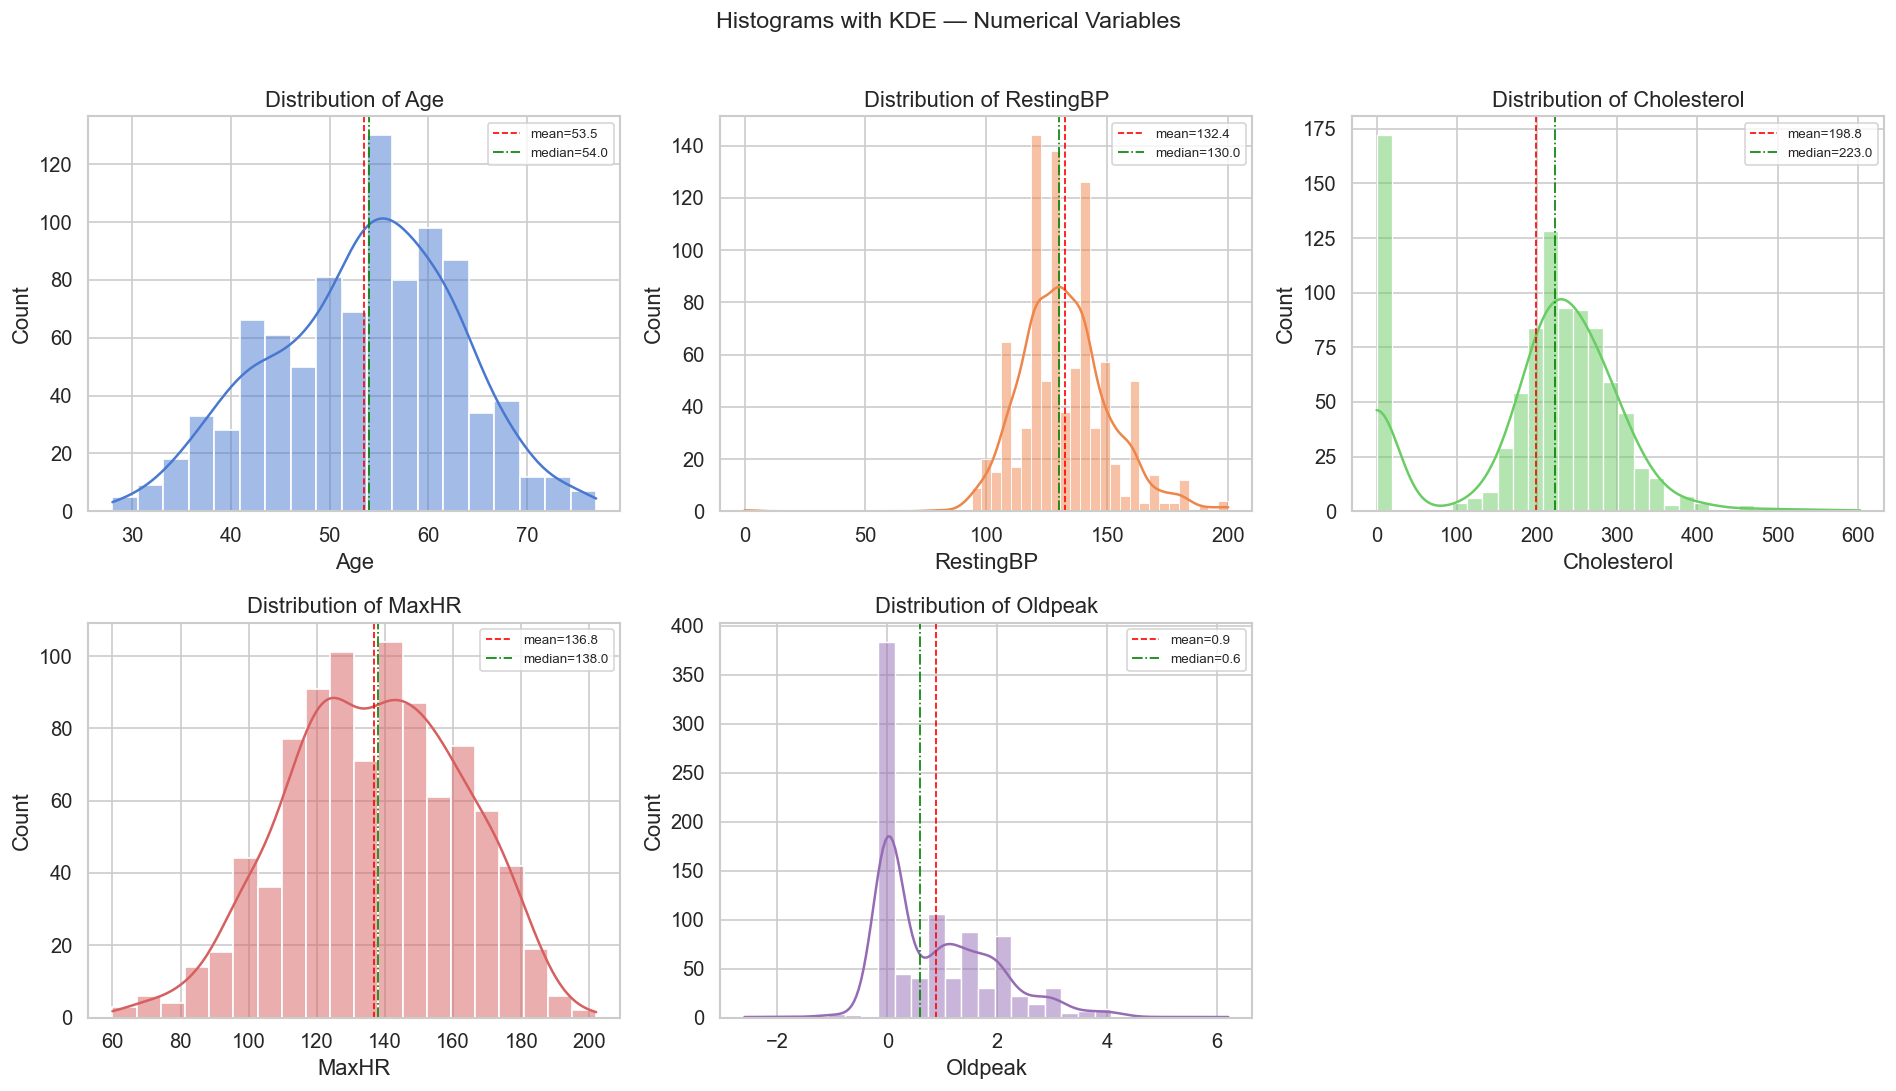

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette()[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].axvline(df[col].mean(), color="red", ls="--", lw=1, label=f"mean={df[col].mean():.1f}")
    axes[i].axvline(df[col].median(), color="green", ls="-.", lw=1, label=f"median={df[col].median():.1f}")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Histograms with KDE — Numerical Variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

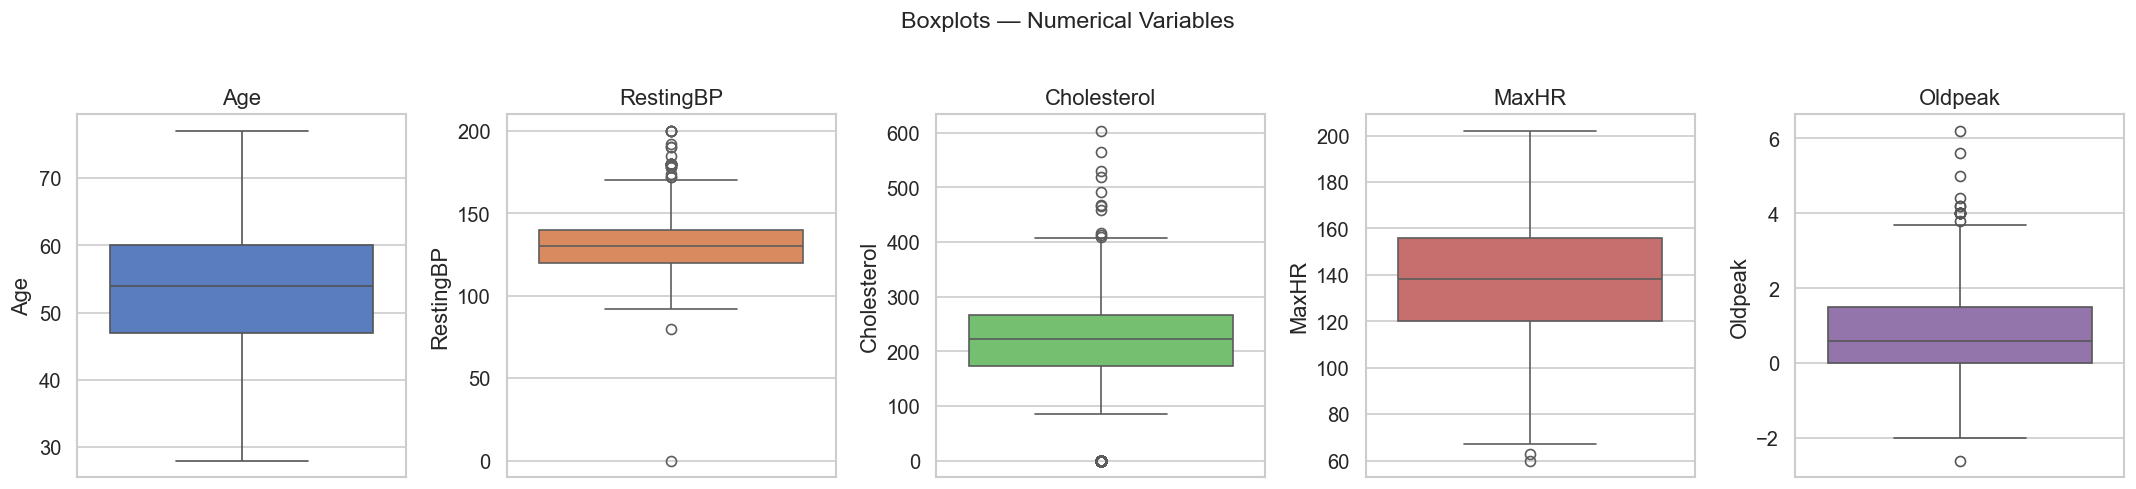

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette()[i])
    axes[i].set_title(col)

plt.suptitle("Boxplots — Numerical Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

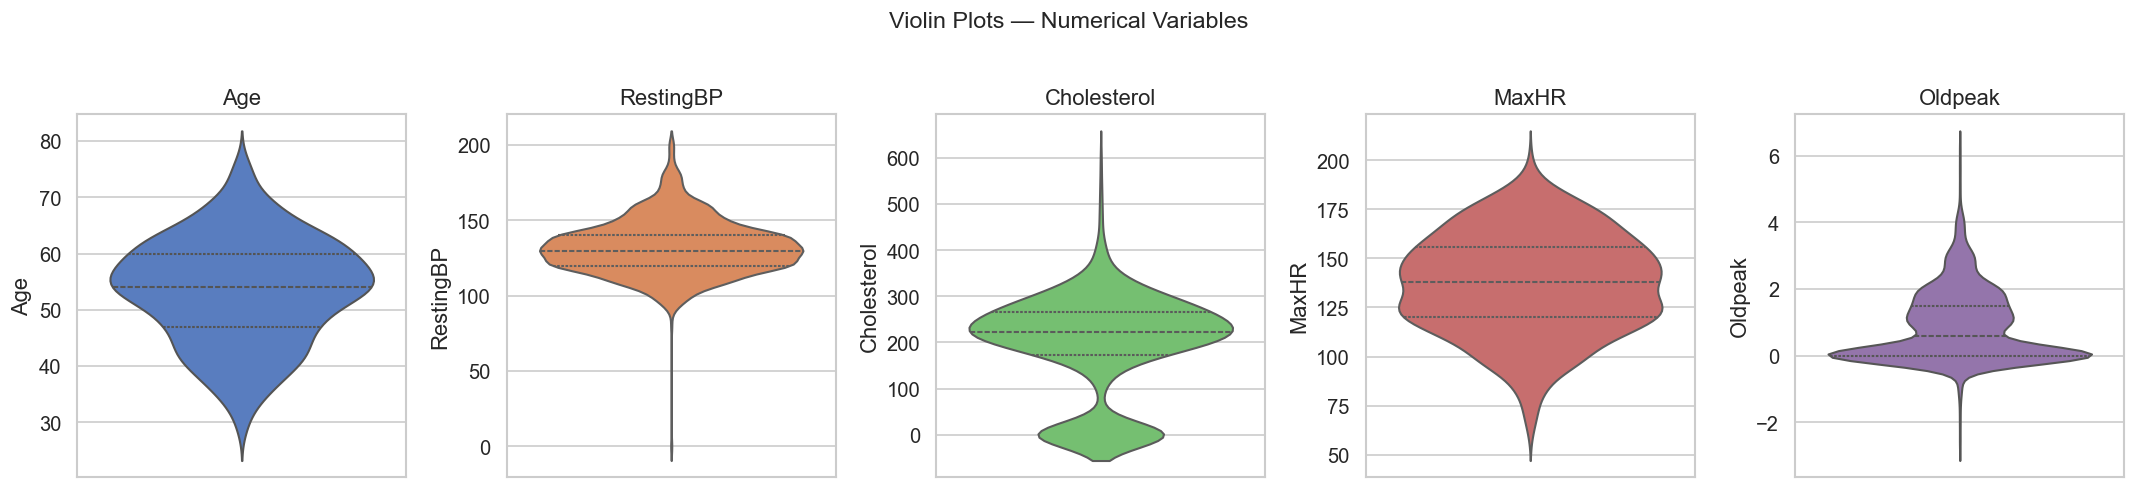

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(num_cols):
    sns.violinplot(y=df[col], ax=axes[i], color=sns.color_palette()[i], inner="quartile")
    axes[i].set_title(col)

plt.suptitle("Violin Plots — Numerical Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1b. Categorical Variables — Frequency Tables & Bar Charts

In [12]:
all_cat = cat_cols + [target]

for col in all_cat:
    freq = pd.DataFrame({
        "Count": df[col].value_counts(),
        "Percent (%)": (df[col].value_counts(normalize=True) * 100).round(2)
    })
    print(f"\n--- {col} ---")
    display(freq)


--- Sex ---


,Count,Percent (%)
Sex,,
M,725,78.98
F,193,21.02



--- ChestPainType ---


,Count,Percent (%)
ChestPainType,,
ASY,496,54.03
NAP,203,22.11
ATA,173,18.85
TA,46,5.01



--- FastingBS ---


...

,Count,Percent (%)
ExerciseAngina,,
N,547,59.59
Y,371,40.41



--- ST_Slope ---


,Count,Percent (%)
ST_Slope,,
Flat,460,50.11
Up,395,43.03
Down,63,6.86



--- HeartDisease ---


,Count,Percent (%)
HeartDisease,,
1,508,55.34
0,410,44.66


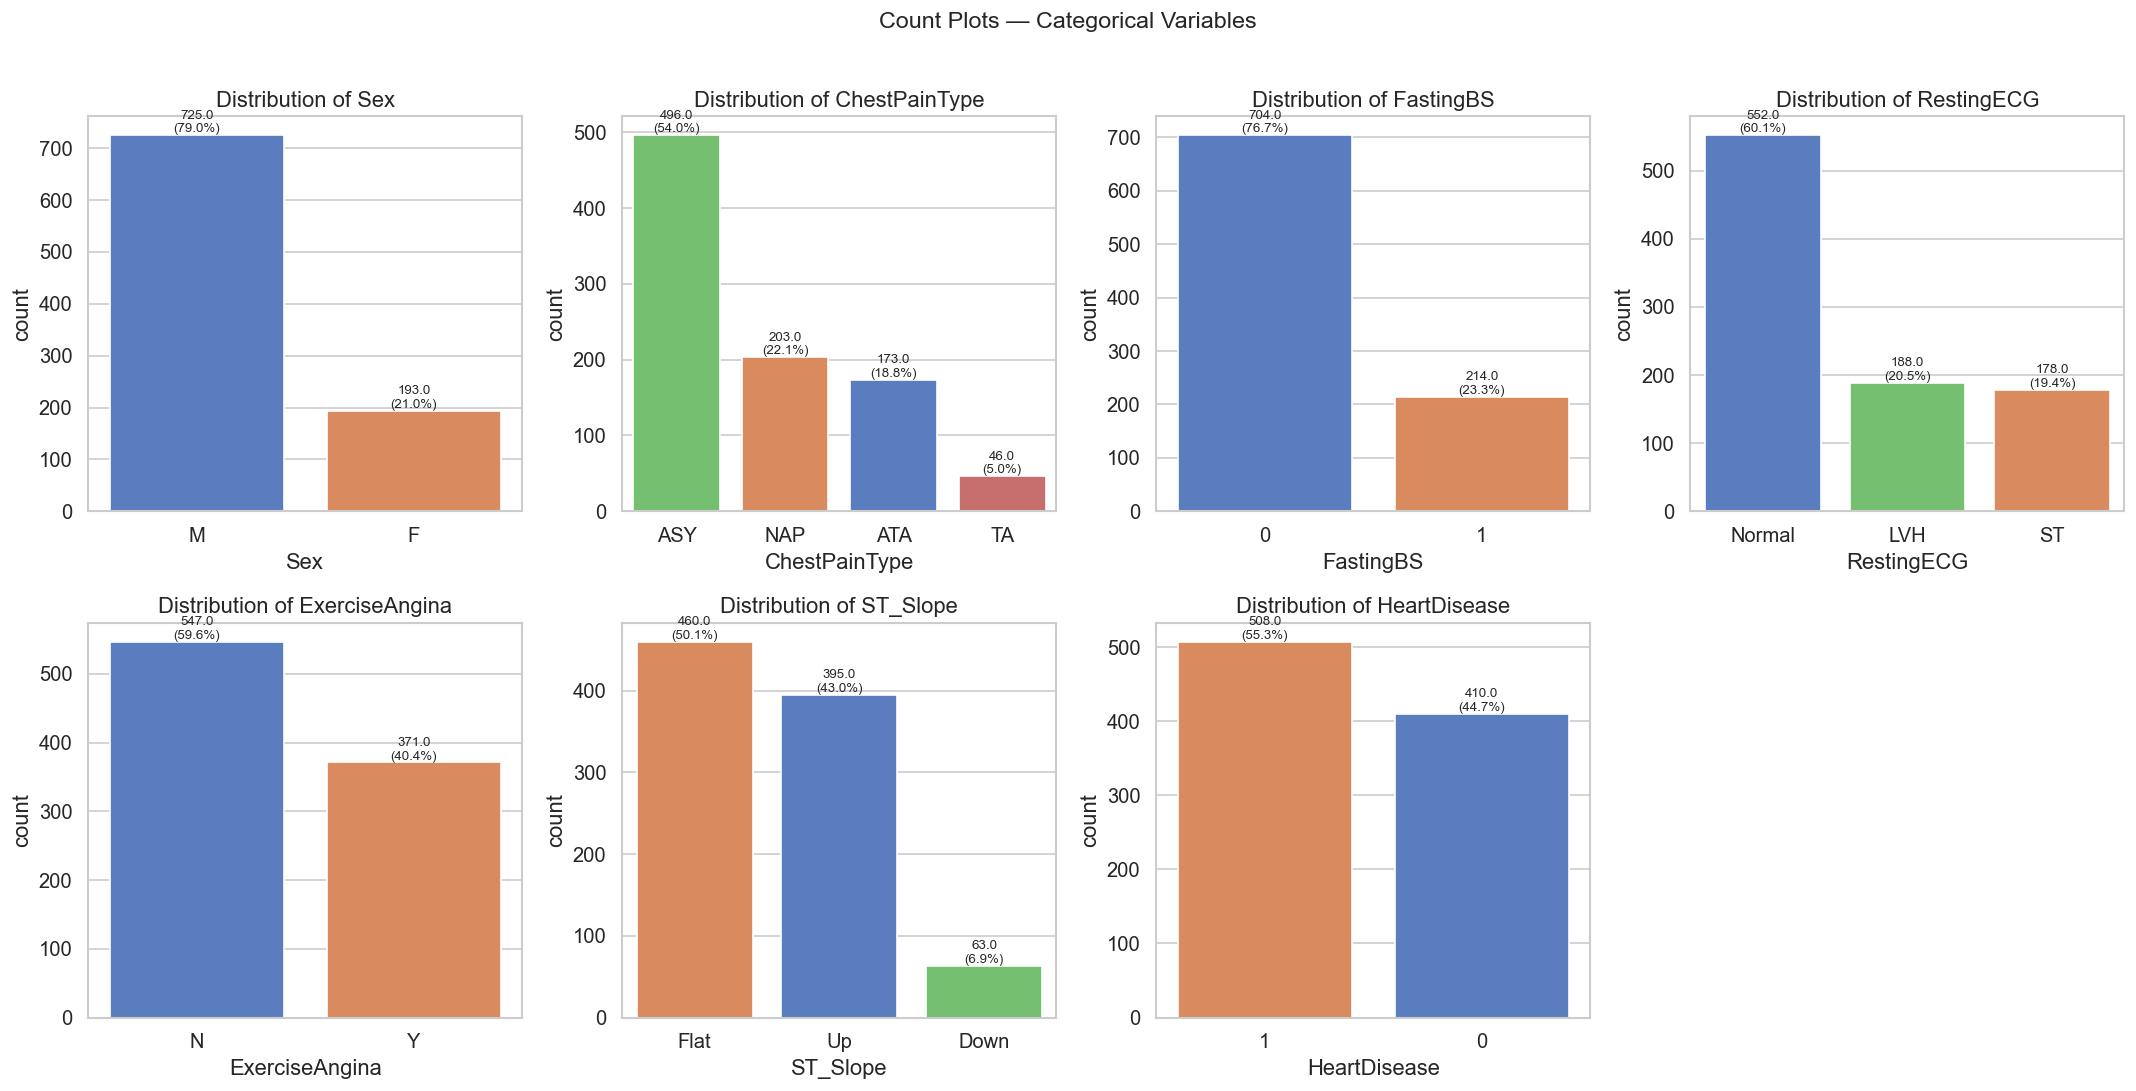

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(all_cat):
    order = df[col].value_counts().index
    ax = axes[i]
    sns.countplot(x=df[col], order=order, ax=ax, hue=df[col], legend=False)
    ax.set_title(f"Distribution of {col}")
    total = len(df)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h}\n({h/total*100:.1f}%)", (p.get_x() + p.get_width() / 2., h),
                     ha="center", va="bottom", fontsize=8)

for j in range(len(all_cat), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Count Plots — Categorical Variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Bivariate / Multivariate Analysis

### 2a. Correlation Analysis (Numerical–Numerical)

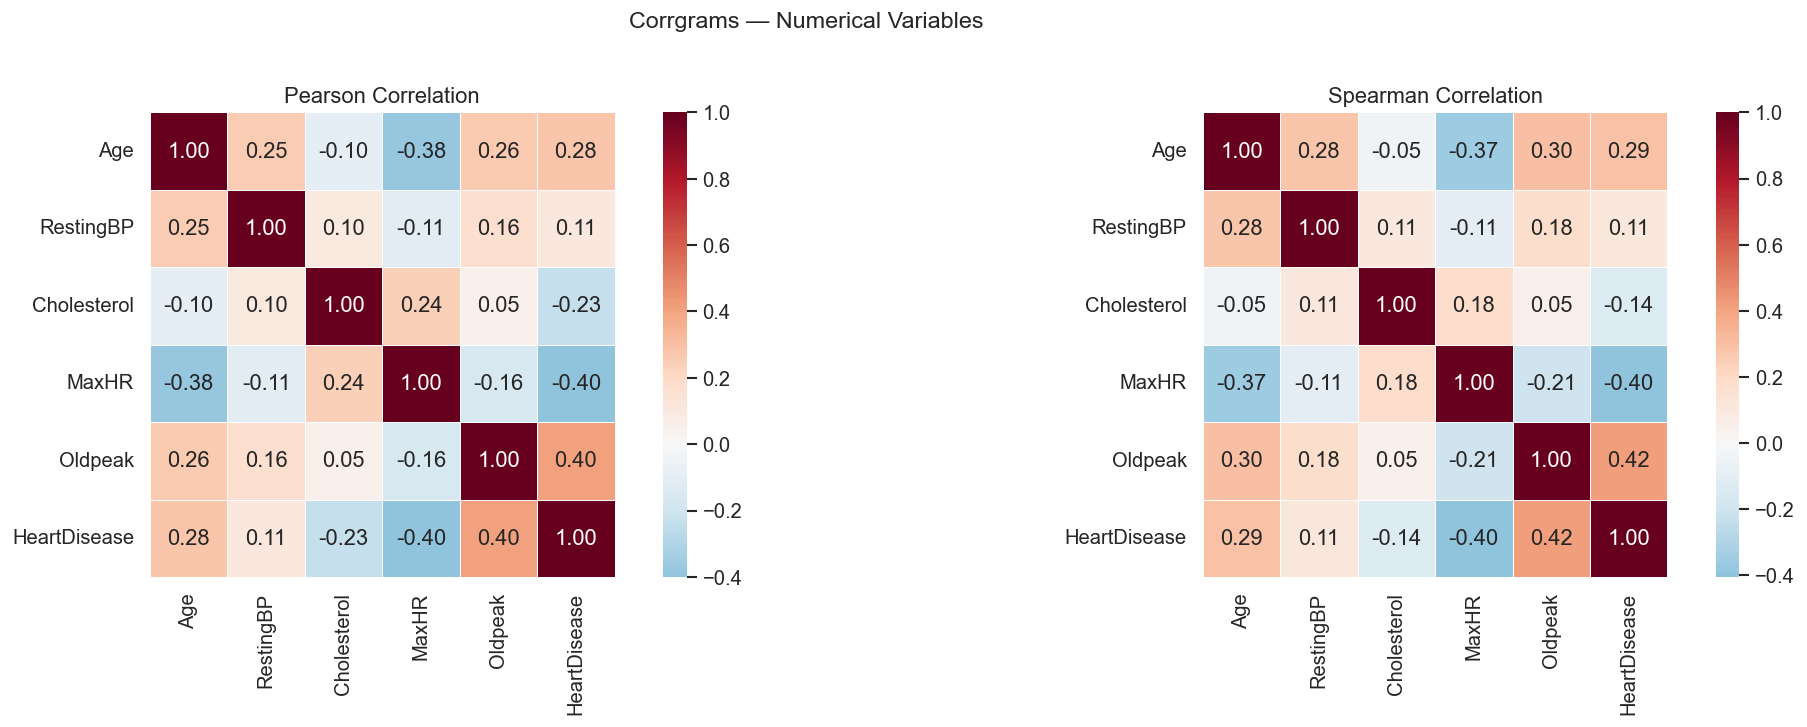

In [14]:
num_with_target = num_cols + [target]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pearson = df[num_with_target].corr(method="pearson")
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0],
            square=True, linewidths=0.5)
axes[0].set_title("Pearson Correlation")

spearman = df[num_with_target].corr(method="spearman")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            square=True, linewidths=0.5)
axes[1].set_title("Spearman Correlation")

plt.suptitle("Corrgrams — Numerical Variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2b. Pair Plot (Scatter Plots on Pairs of Numerical Variables)

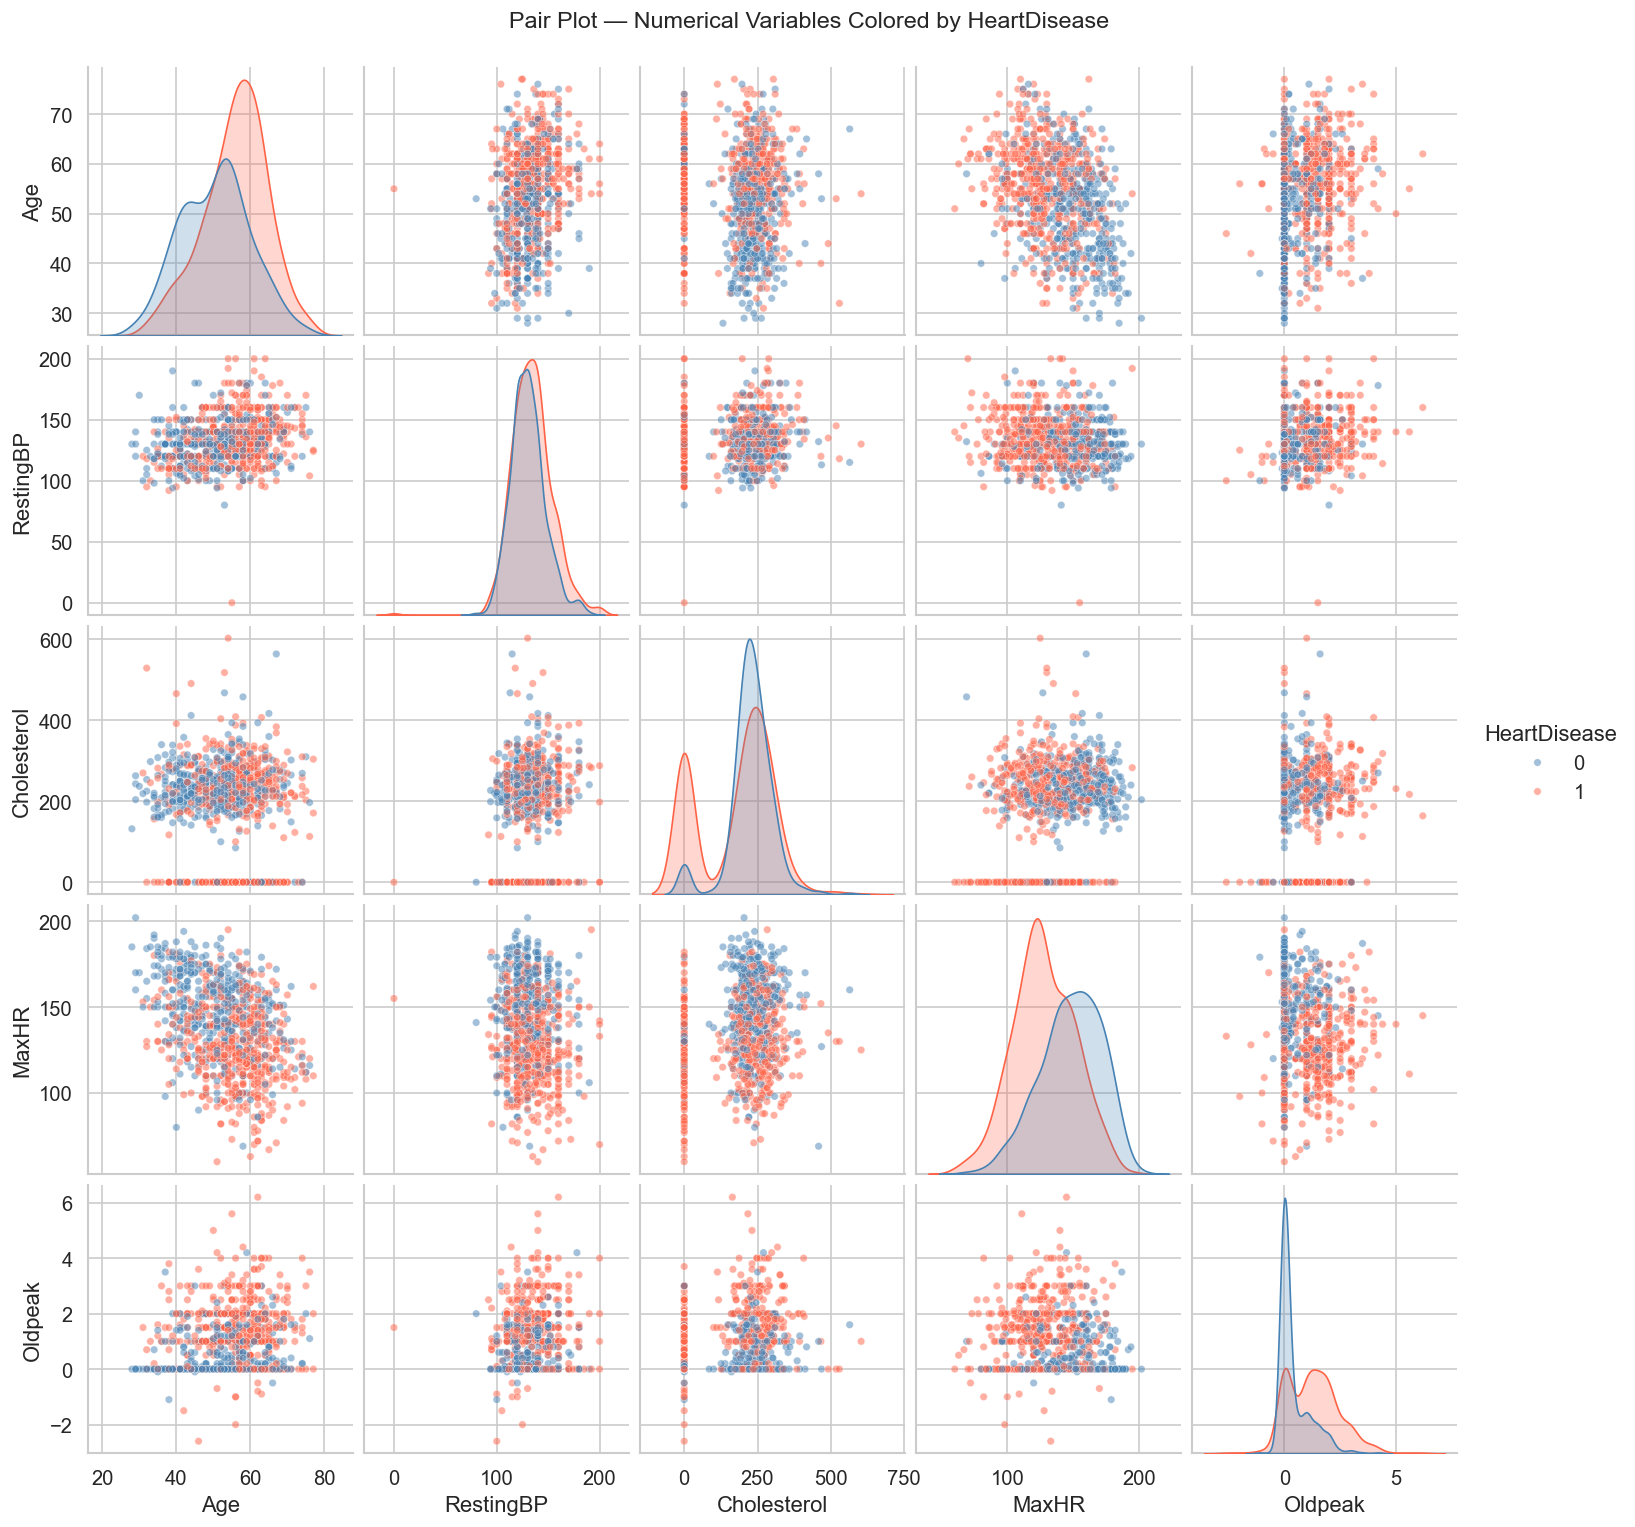

In [15]:
g = sns.pairplot(df[num_with_target], hue="HeartDisease",
                 palette={0: "steelblue", 1: "tomato"},
                 diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20})
g.figure.suptitle("Pair Plot — Numerical Variables Colored by HeartDisease", y=1.02, fontsize=14)
plt.show()

### 2c. 3D Scatter Plot

In [16]:
fig = px.scatter_3d(
    df, x="Age", y="MaxHR", z="Oldpeak",
    color=df["HeartDisease"].map({0: "Normal", 1: "Heart Disease"}),
    color_discrete_map={"Normal": "steelblue", "Heart Disease": "tomato"},
    opacity=0.6,
    title="3D Scatter: Age × MaxHR × Oldpeak (colored by HeartDisease)",
    labels={"color": "HeartDisease"}
)
fig.update_layout(width=800, height=600)
fig.show()

### 2d. Dimensionality Reduction Visualizations

Encode categorical variables, standardize all features, and project into 2D via PCA, t-SNE, UMAP, and Sammon mapping (metric MDS).

In [17]:
df_enc = df.copy()
le_map = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    le_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

feature_cols = num_cols + cat_cols
X = df_enc[feature_cols].values
y = df_enc[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

labels = np.where(y == 1, "Heart Disease", "Normal")

Explained variance: PC1=0.251, PC2=0.133, Total=0.384


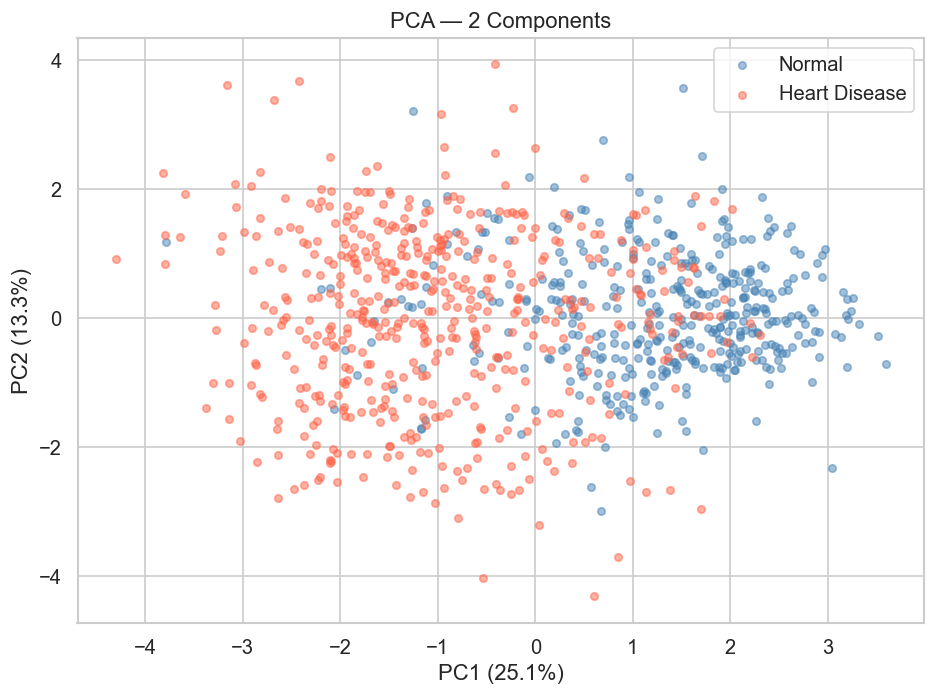

In [18]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_):.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [("Normal", "steelblue"), ("Heart Disease", "tomato")]:
    mask = labels == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, alpha=0.5, s=20)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — 2 Components")
ax.legend()
plt.tight_layout()
plt.show()

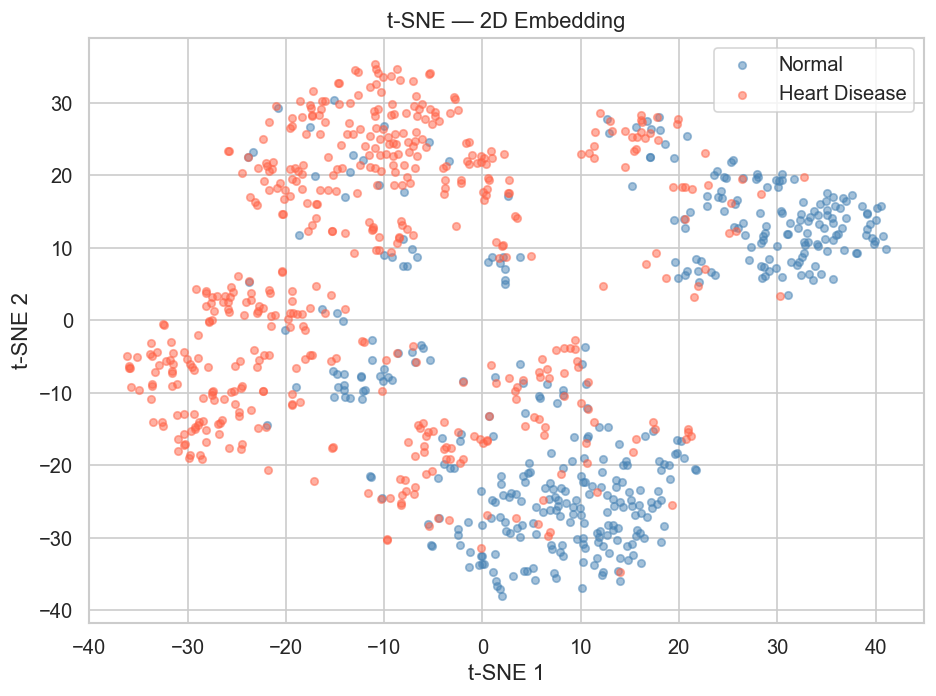

In [19]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [("Normal", "steelblue"), ("Heart Disease", "tomato")]:
    mask = labels == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=label, alpha=0.5, s=20)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE — 2D Embedding")
ax.legend()
plt.tight_layout()
plt.show()

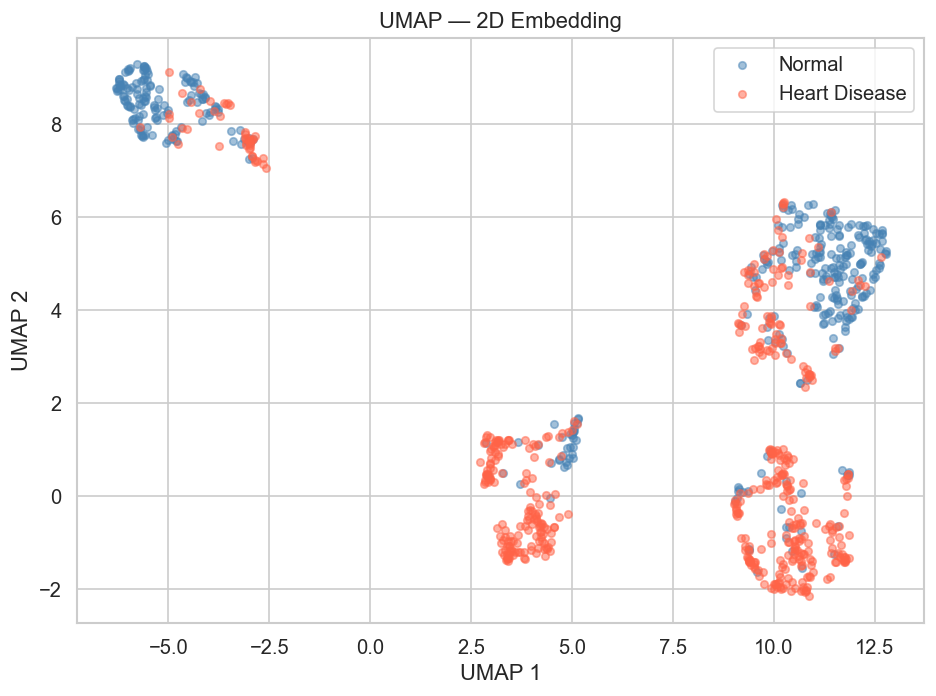

In [20]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [("Normal", "steelblue"), ("Heart Disease", "tomato")]:
    mask = labels == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], c=color, label=label, alpha=0.5, s=20)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — 2D Embedding")
ax.legend()
plt.tight_layout()
plt.show()

Sammon (metric MDS) stress: 814922.5238


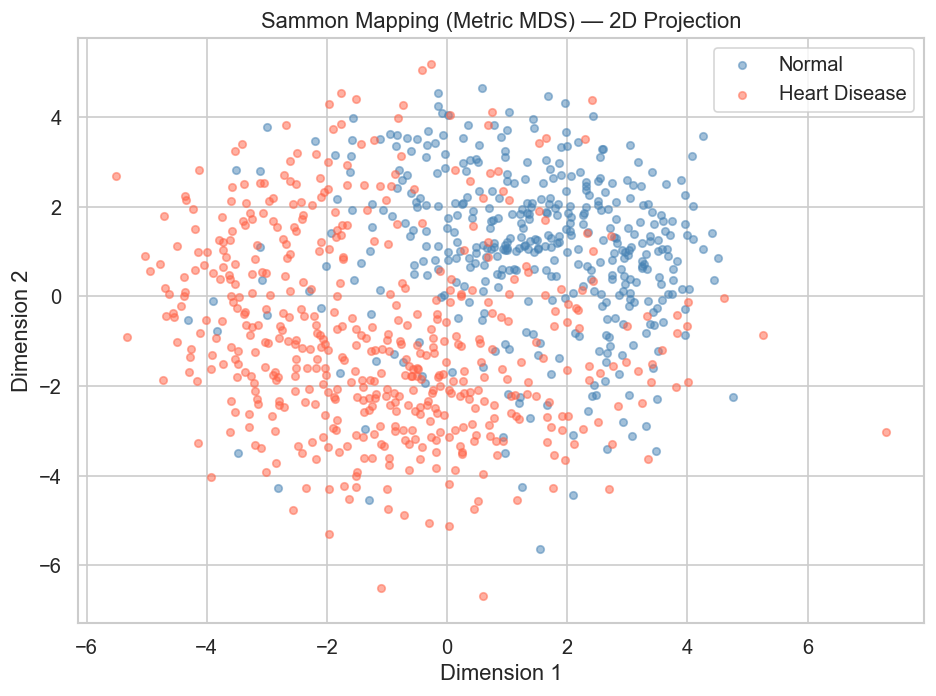

In [21]:
D_high = squareform(pdist(X_scaled, metric="euclidean"))

mds = MDS(n_components=2, metric=True, dissimilarity="precomputed",
          random_state=42, n_init=4, max_iter=300, normalized_stress="auto")
X_sammon = mds.fit_transform(D_high)
print(f"Sammon (metric MDS) stress: {mds.stress_:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [("Normal", "steelblue"), ("Heart Disease", "tomato")]:
    mask = labels == label
    ax.scatter(X_sammon[mask, 0], X_sammon[mask, 1], c=color, label=label, alpha=0.5, s=20)
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Sammon Mapping (Metric MDS) — 2D Projection")
ax.legend()
plt.tight_layout()
plt.show()

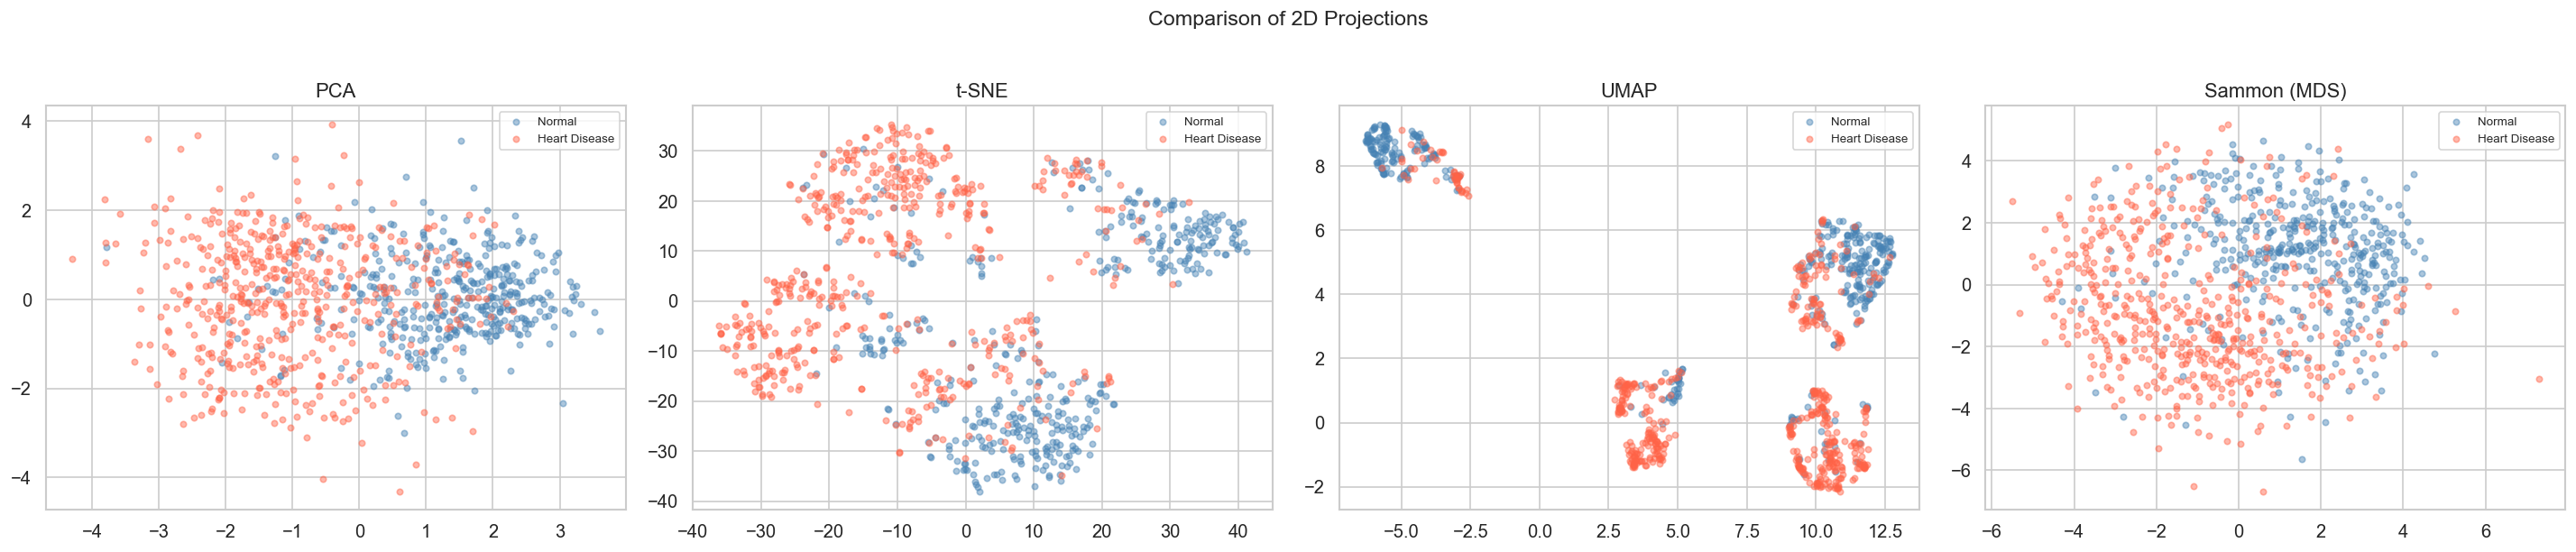

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
embeddings = [("PCA", X_pca), ("t-SNE", X_tsne), ("UMAP", X_umap), ("Sammon (MDS)", X_sammon)]

for ax, (name, emb) in zip(axes, embeddings):
    for label, color in [("Normal", "steelblue"), ("Heart Disease", "tomato")]:
        mask = labels == label
        ax.scatter(emb[mask, 0], emb[mask, 1], c=color, label=label, alpha=0.45, s=15)
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Comparison of 2D Projections", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2e. Categorical–Categorical Associations (Chi-Squared & Cramér's V)

In [23]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0
    return v, chi2, p, dof

all_cat_with_target = cat_cols + [target]

chi2_results = []
for i in range(len(all_cat_with_target)):
    for j in range(i + 1, len(all_cat_with_target)):
        c1, c2 = all_cat_with_target[i], all_cat_with_target[j]
        v, chi2, p, dof = cramers_v(df[c1], df[c2])
        chi2_results.append({"Var1": c1, "Var2": c2, "Chi2": chi2, "p-value": p, "dof": dof, "Cramér's V": v})

chi2_df = pd.DataFrame(chi2_results).sort_values("Cramér's V", ascending=False)
chi2_df.style.format({"Chi2": "{:.2f}", "p-value": "{:.2e}", "Cramér's V": "{:.3f}"})

,Var1,Var2,Chi2,p-value,dof,Cramér's V
20,ST_Slope,HeartDisease,355.92,5.17e-78,2,0.623
10,ChestPainType,HeartDisease,268.07,8.08e-58,3,0.540
19,ExerciseAngina,HeartDisease,222.26,2.91e-50,1,0.492
18,ExerciseAngina,ST_Slope,191.43,2.70e-42,2,0.457
8,ChestPainType,ExerciseAngina,179.27,1.27e-38,3,0.442
5,Sex,HeartDisease,84.15,4.60e-20,1,0.303
9,ChestPainType,ST_Slope,156.88,2.71e-31,6,0.292
14,FastingBS,HeartDisease,64.32,1.06e-15,1,0.265
0,Sex,ChestPainType,36.88,4.88e-08,3,0.200
3,Sex,ExerciseAngina,32.43,1.24e-08,1,0.188


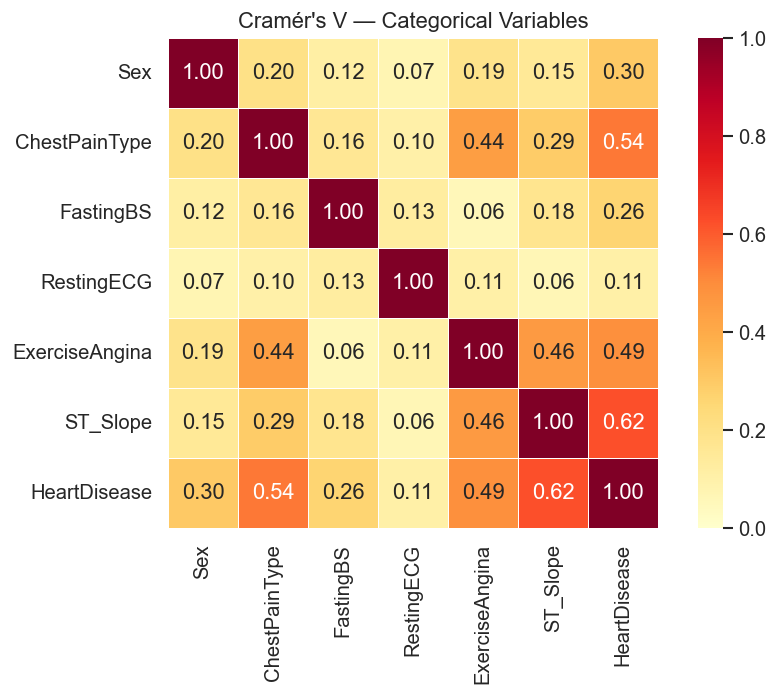

In [24]:
cramer_matrix = pd.DataFrame(np.zeros((len(all_cat_with_target), len(all_cat_with_target))),
                              index=all_cat_with_target, columns=all_cat_with_target)
for _, row in chi2_df.iterrows():
    cramer_matrix.loc[row["Var1"], row["Var2"]] = row["Cramér's V"]
    cramer_matrix.loc[row["Var2"], row["Var1"]] = row["Cramér's V"]
for c in all_cat_with_target:
    cramer_matrix.loc[c, c] = 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            square=True, linewidths=0.5, vmin=0, vmax=1)
plt.title("Cramér's V — Categorical Variables")
plt.tight_layout()
plt.show()

### 2f. Numerical–Categorical Tests (Mean Comparison)

In [25]:
print("=" * 70)
print("T-tests & Mann-Whitney U: numerical variables across HeartDisease")
print("=" * 70)

test_rows = []
for col in num_cols:
    g0 = df.loc[df[target] == 0, col]
    g1 = df.loc[df[target] == 1, col]
    t_stat, t_p = ttest_ind(g0, g1, equal_var=False)
    u_stat, u_p = mannwhitneyu(g0, g1, alternative="two-sided")
    test_rows.append({
        "Variable": col,
        "Mean (0)": g0.mean(), "Mean (1)": g1.mean(),
        "t-stat": t_stat, "t p-value": t_p,
        "U-stat": u_stat, "MWU p-value": u_p,
    })

test_df = pd.DataFrame(test_rows)
test_df.style.format({
    "Mean (0)": "{:.2f}", "Mean (1)": "{:.2f}",
    "t-stat": "{:.3f}", "t p-value": "{:.2e}",
    "U-stat": "{:.0f}", "MWU p-value": "{:.2e}",
})

T-tests & Mann-Whitney U: numerical variables across HeartDisease


,Variable,Mean (0),Mean (1),t-stat,t p-value,U-stat,MWU p-value
0,Age,50.55,55.90,-8.823,6.35e-18,69138,1.81e-18
1,RestingBP,130.18,134.19,-3.339,8.73e-04,90420,5.65e-04
2,Cholesterol,227.12,175.94,7.627,6.48e-14,121000,2.28e-05
3,MaxHR,148.15,127.66,13.231,1.43e-36,153090,1.51e-34
4,Oldpeak,0.41,1.27,-14.040,1.90e-40,55164,6.77e-37


In [26]:
print("=" * 70)
print("Kruskal-Wallis: numerical variables across ChestPainType groups")
print("=" * 70)

kw_rows = []
for col in num_cols:
    groups = [g[col].values for _, g in df.groupby("ChestPainType")]
    h_stat, h_p = kruskal(*groups)
    kw_rows.append({"Variable": col, "H-stat": h_stat, "p-value": h_p})

pd.DataFrame(kw_rows).style.format({"H-stat": "{:.3f}", "p-value": "{:.2e}"})

Kruskal-Wallis: numerical variables across ChestPainType groups


,Variable,H-stat,p-value
0,Age,48.599,1.59e-10
1,RestingBP,7.540,5.65e-02
2,Cholesterol,14.345,2.47e-03
3,MaxHR,126.249,3.48e-27
4,Oldpeak,109.552,1.37e-23


### 2g. Conditional Boxplots

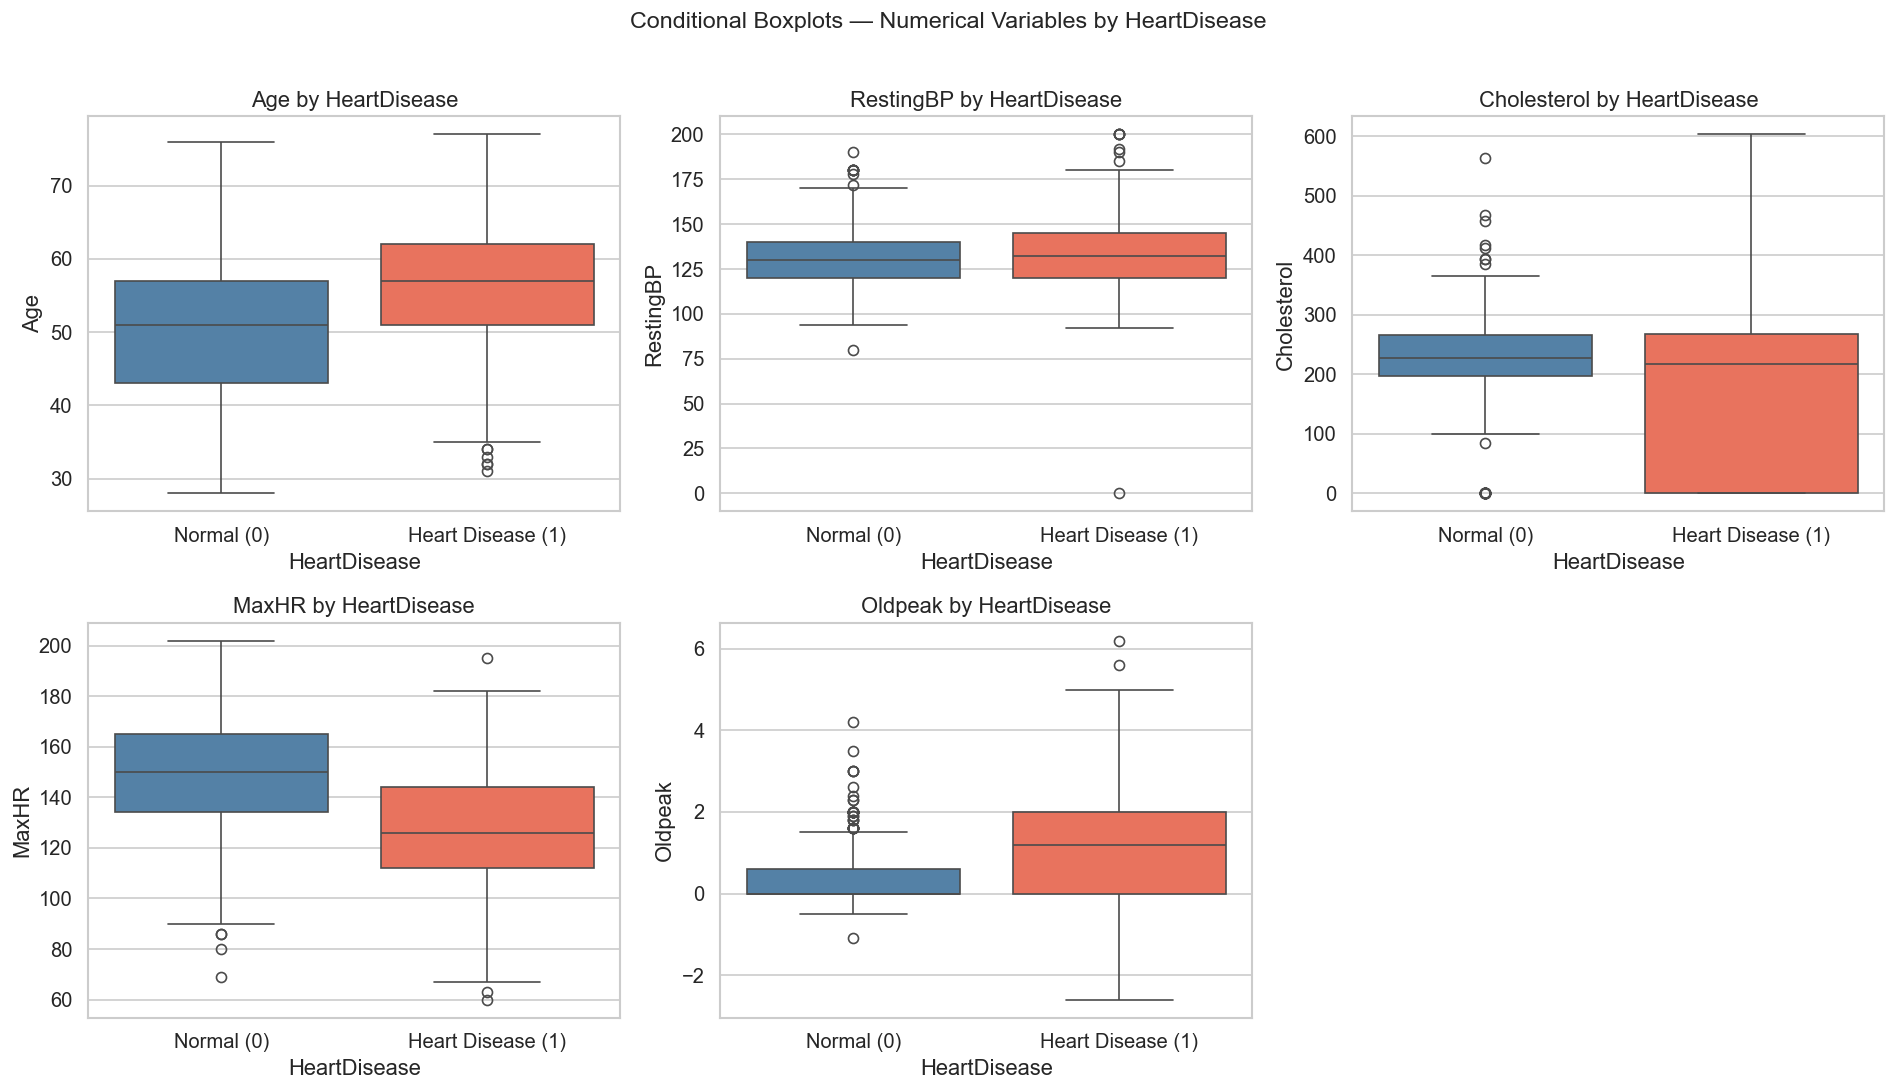

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=target, y=col, data=df, ax=axes[i],
                hue=target, palette={0: "steelblue", 1: "tomato"}, legend=False)
    axes[i].set_title(f"{col} by HeartDisease")
    axes[i].set_xticklabels(["Normal (0)", "Heart Disease (1)"])

axes[-1].set_visible(False)
plt.suptitle("Conditional Boxplots — Numerical Variables by HeartDisease", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

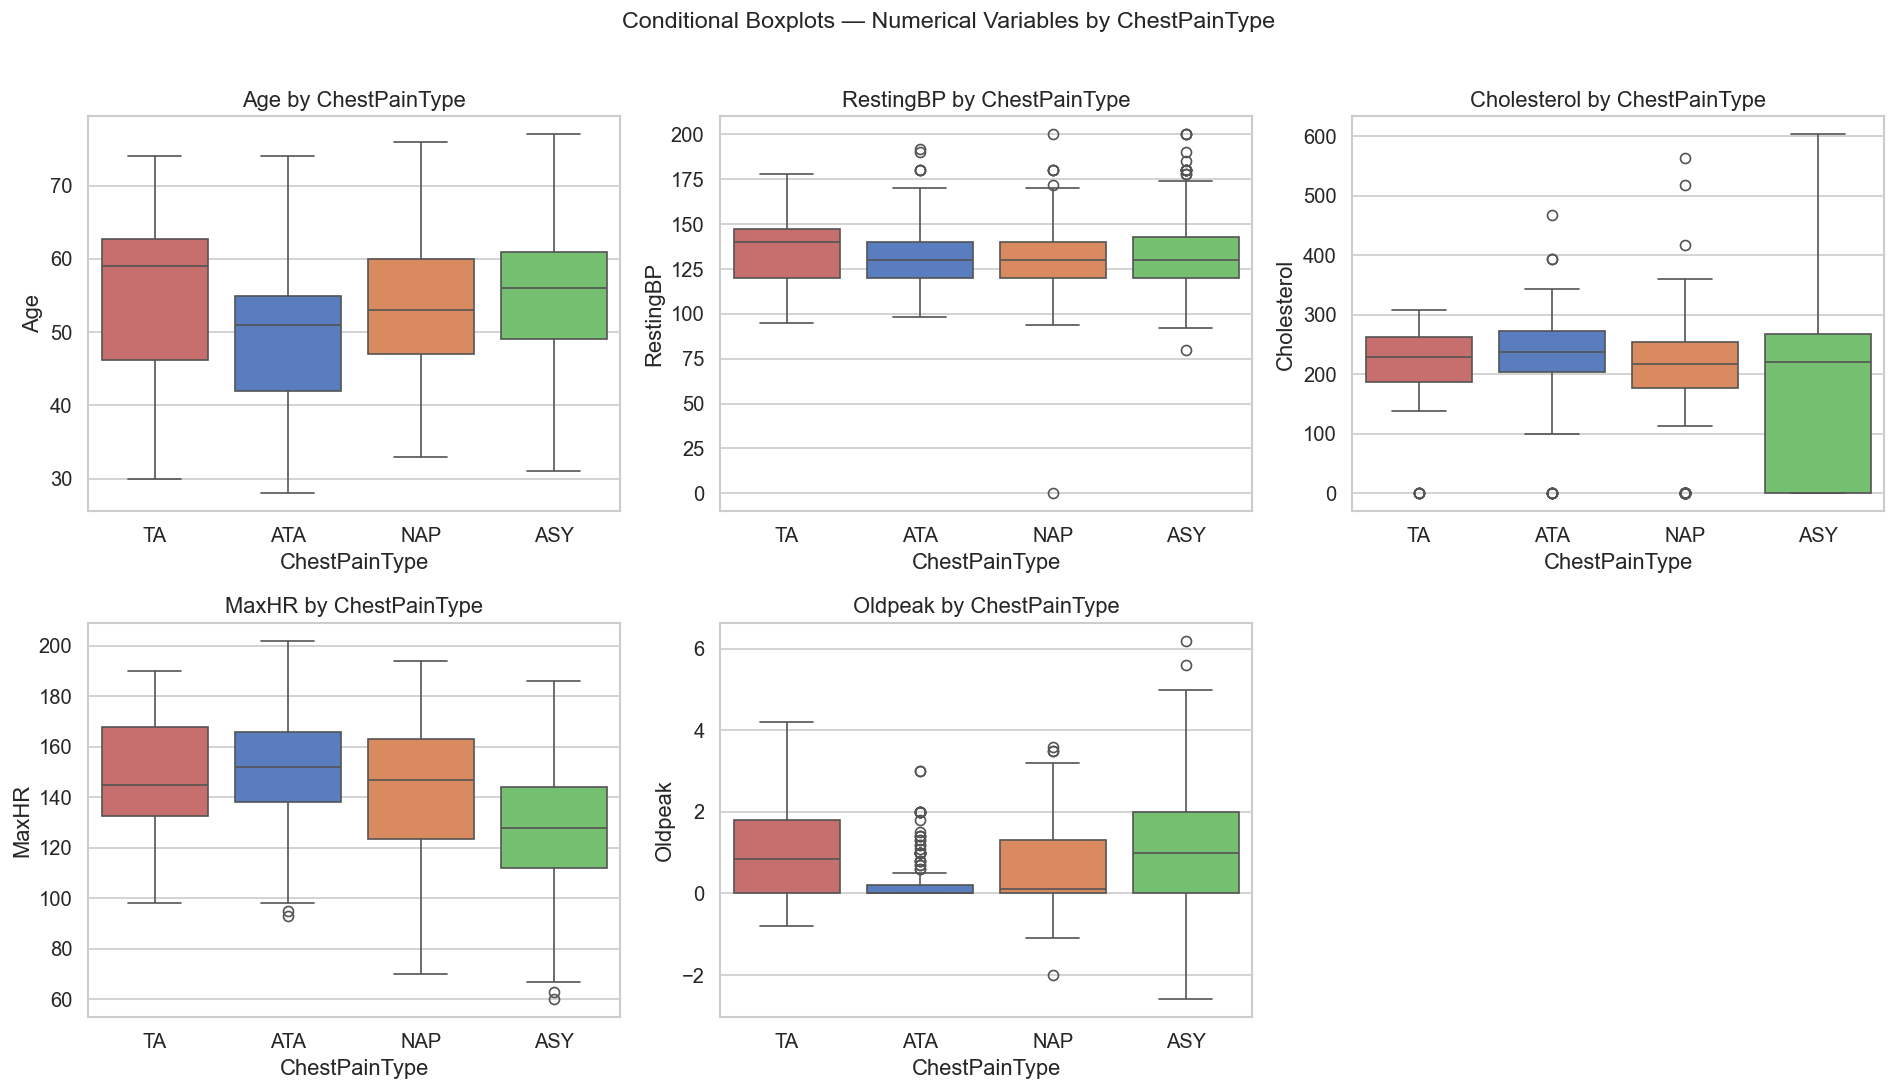

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x="ChestPainType", y=col, data=df, ax=axes[i],
                hue="ChestPainType", order=["TA", "ATA", "NAP", "ASY"])
    axes[i].set_title(f"{col} by ChestPainType")

axes[-1].set_visible(False)
plt.suptitle("Conditional Boxplots — Numerical Variables by ChestPainType", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2h. Stacked & Overlapping Histograms

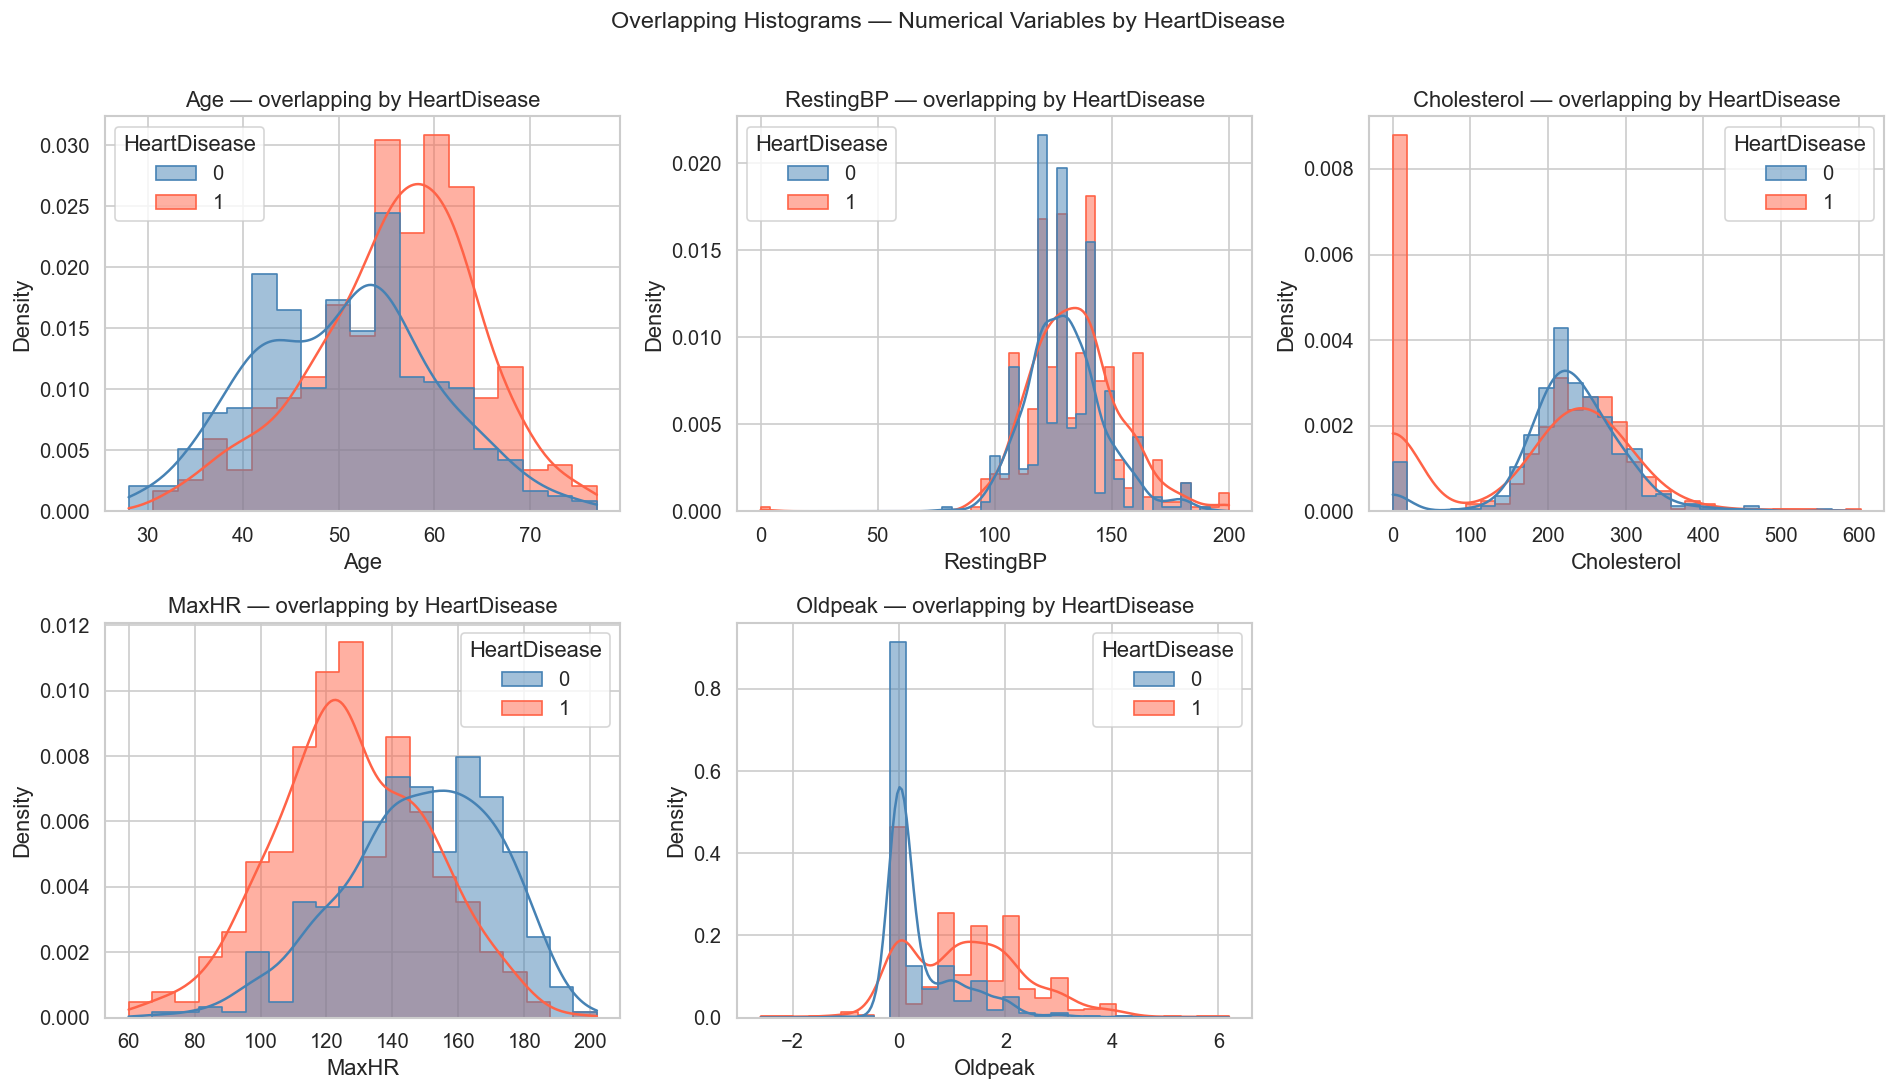

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue=target, kde=True, ax=axes[i],
                 palette={0: "steelblue", 1: "tomato"}, alpha=0.5,
                 element="step", stat="density")
    axes[i].set_title(f"{col} — overlapping by HeartDisease")

axes[-1].set_visible(False)
plt.suptitle("Overlapping Histograms — Numerical Variables by HeartDisease", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

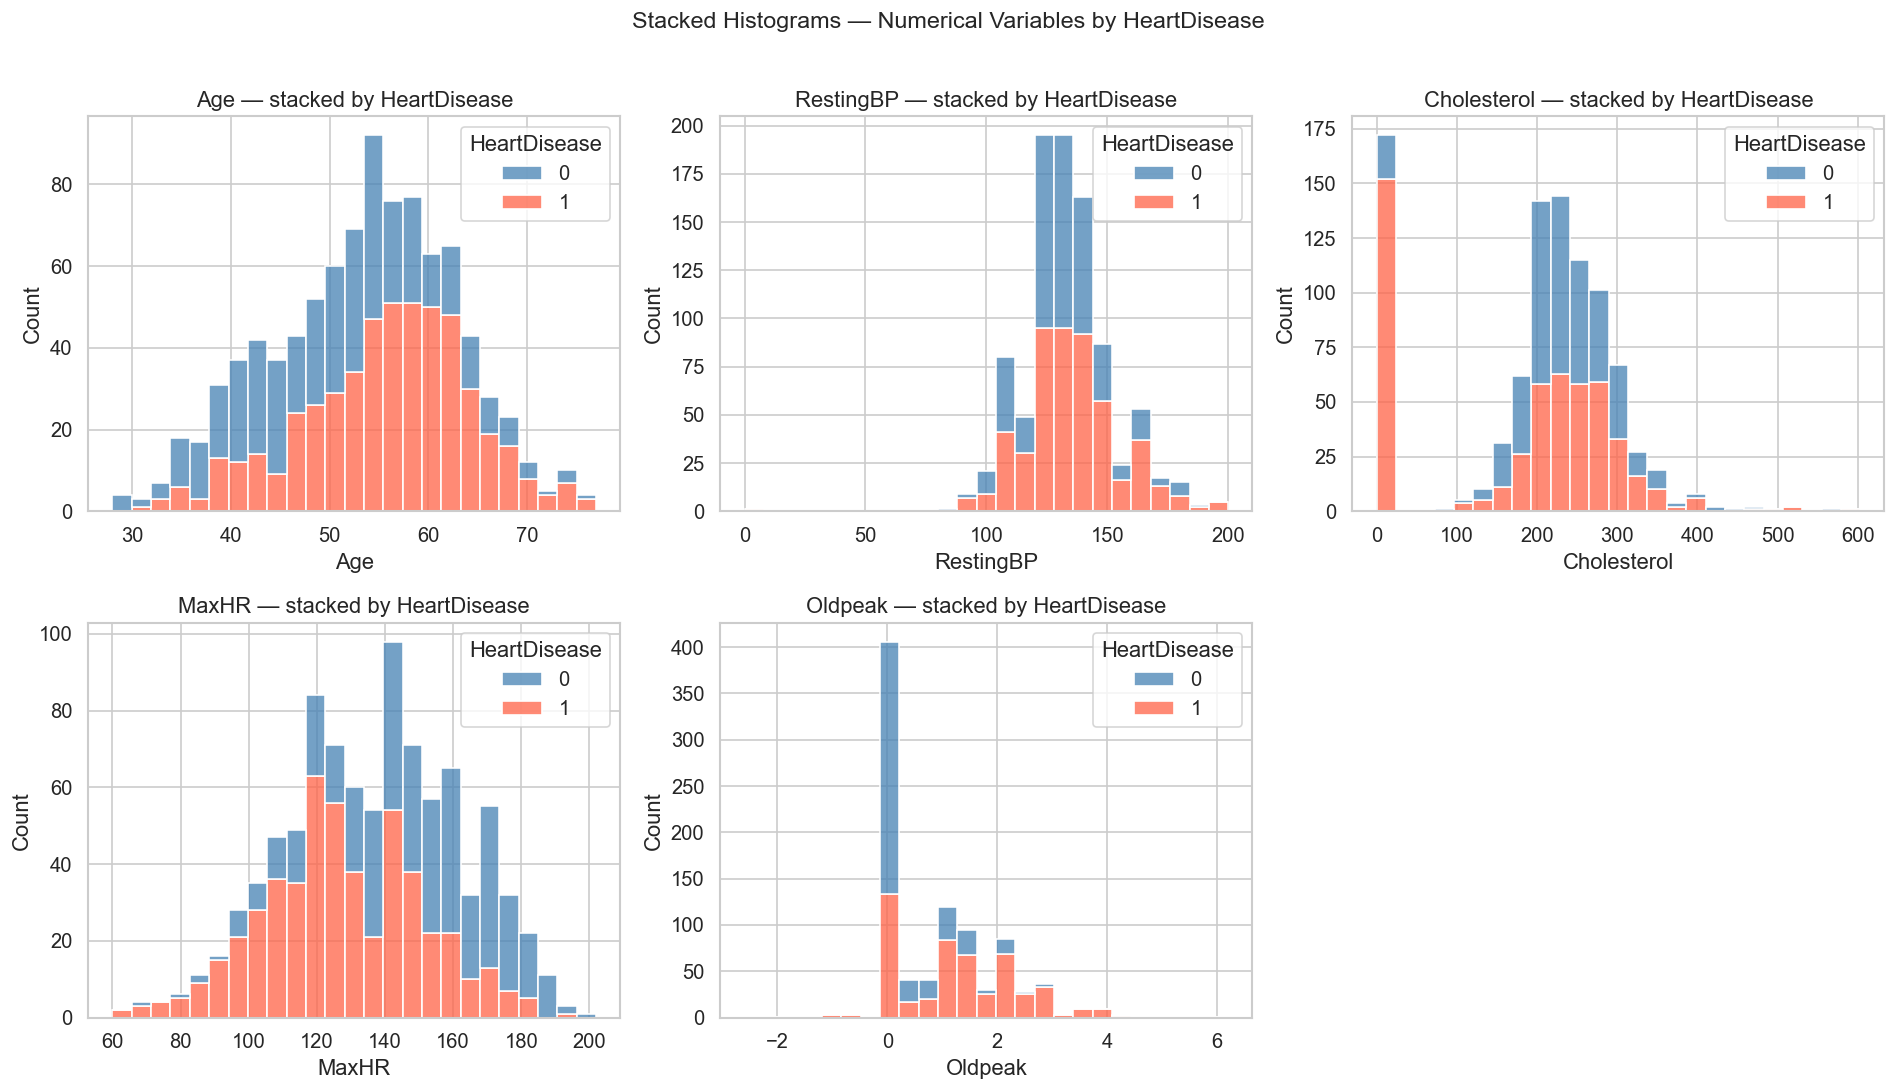

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue=target, ax=axes[i],
                 palette={0: "steelblue", 1: "tomato"},
                 multiple="stack", stat="count", bins=25)
    axes[i].set_title(f"{col} — stacked by HeartDisease")

axes[-1].set_visible(False)
plt.suptitle("Stacked Histograms — Numerical Variables by HeartDisease", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Predictive Power for HeartDisease Target

### 3a. Numerical Predictors

In [31]:
num_pred_rows = []
for col in num_cols:
    g0 = df.loc[df[target] == 0, col]
    g1 = df.loc[df[target] == 1, col]

    rpb, rpb_p = pointbiserialr(df[target], df[col])
    u_stat, u_p = mannwhitneyu(g0, g1, alternative="two-sided")

    num_pred_rows.append({
        "Variable": col,
        "Point-Biserial r": rpb,
        "PB p-value": rpb_p,
        "|r|": abs(rpb),
        "Mann-Whitney U": u_stat,
        "MWU p-value": u_p,
    })

num_pred_df = pd.DataFrame(num_pred_rows).sort_values("|r|", ascending=False)

print("Numerical features ranked by |Point-Biserial r| with HeartDisease:\n")
num_pred_df.style.format({
    "Point-Biserial r": "{:.4f}", "PB p-value": "{:.2e}", "|r|": "{:.4f}",
    "Mann-Whitney U": "{:.0f}", "MWU p-value": "{:.2e}",
}).bar(subset=["|r|"], color="#ff7f0e")

Numerical features ranked by |Point-Biserial r| with HeartDisease:



,Variable,Point-Biserial r,PB p-value,|r|,Mann-Whitney U,MWU p-value
4,Oldpeak,0.4040,2.39e-37,0.4040,55164,6.77e-37
3,MaxHR,-0.4004,1.14e-36,0.4004,153090,1.51e-34
0,Age,0.2820,3.01e-18,0.2820,69138,1.81e-18
2,Cholesterol,-0.2327,9.31e-13,0.2327,121000,2.28e-05
1,RestingBP,0.1076,1.10e-03,0.1076,90420,5.65e-04


### 3b. Categorical Predictors

In [32]:
cat_pred_rows = []
for col in cat_cols:
    v, chi2, p, dof = cramers_v(df[col], df[target])
    cat_pred_rows.append({
        "Variable": col,
        "Chi-Squared": chi2,
        "p-value": p,
        "dof": dof,
        "Cramér's V": v,
    })

cat_pred_df = pd.DataFrame(cat_pred_rows).sort_values("Cramér's V", ascending=False)

print("Categorical features ranked by Cramér's V with HeartDisease:\n")
cat_pred_df.style.format({
    "Chi-Squared": "{:.2f}", "p-value": "{:.2e}", "Cramér's V": "{:.4f}",
}).bar(subset=["Cramér's V"], color="#ff7f0e")

Categorical features ranked by Cramér's V with HeartDisease:



,Variable,Chi-Squared,p-value,dof,Cramér's V
5,ST_Slope,355.92,5.17e-78,2,0.6227
1,ChestPainType,268.07,8.08e-58,3,0.5404
4,ExerciseAngina,222.26,2.91e-50,1,0.4920
0,Sex,84.15,4.60e-20,1,0.3028
2,FastingBS,64.32,1.06e-15,1,0.2647
3,RestingECG,10.93,4.23e-03,2,0.1091


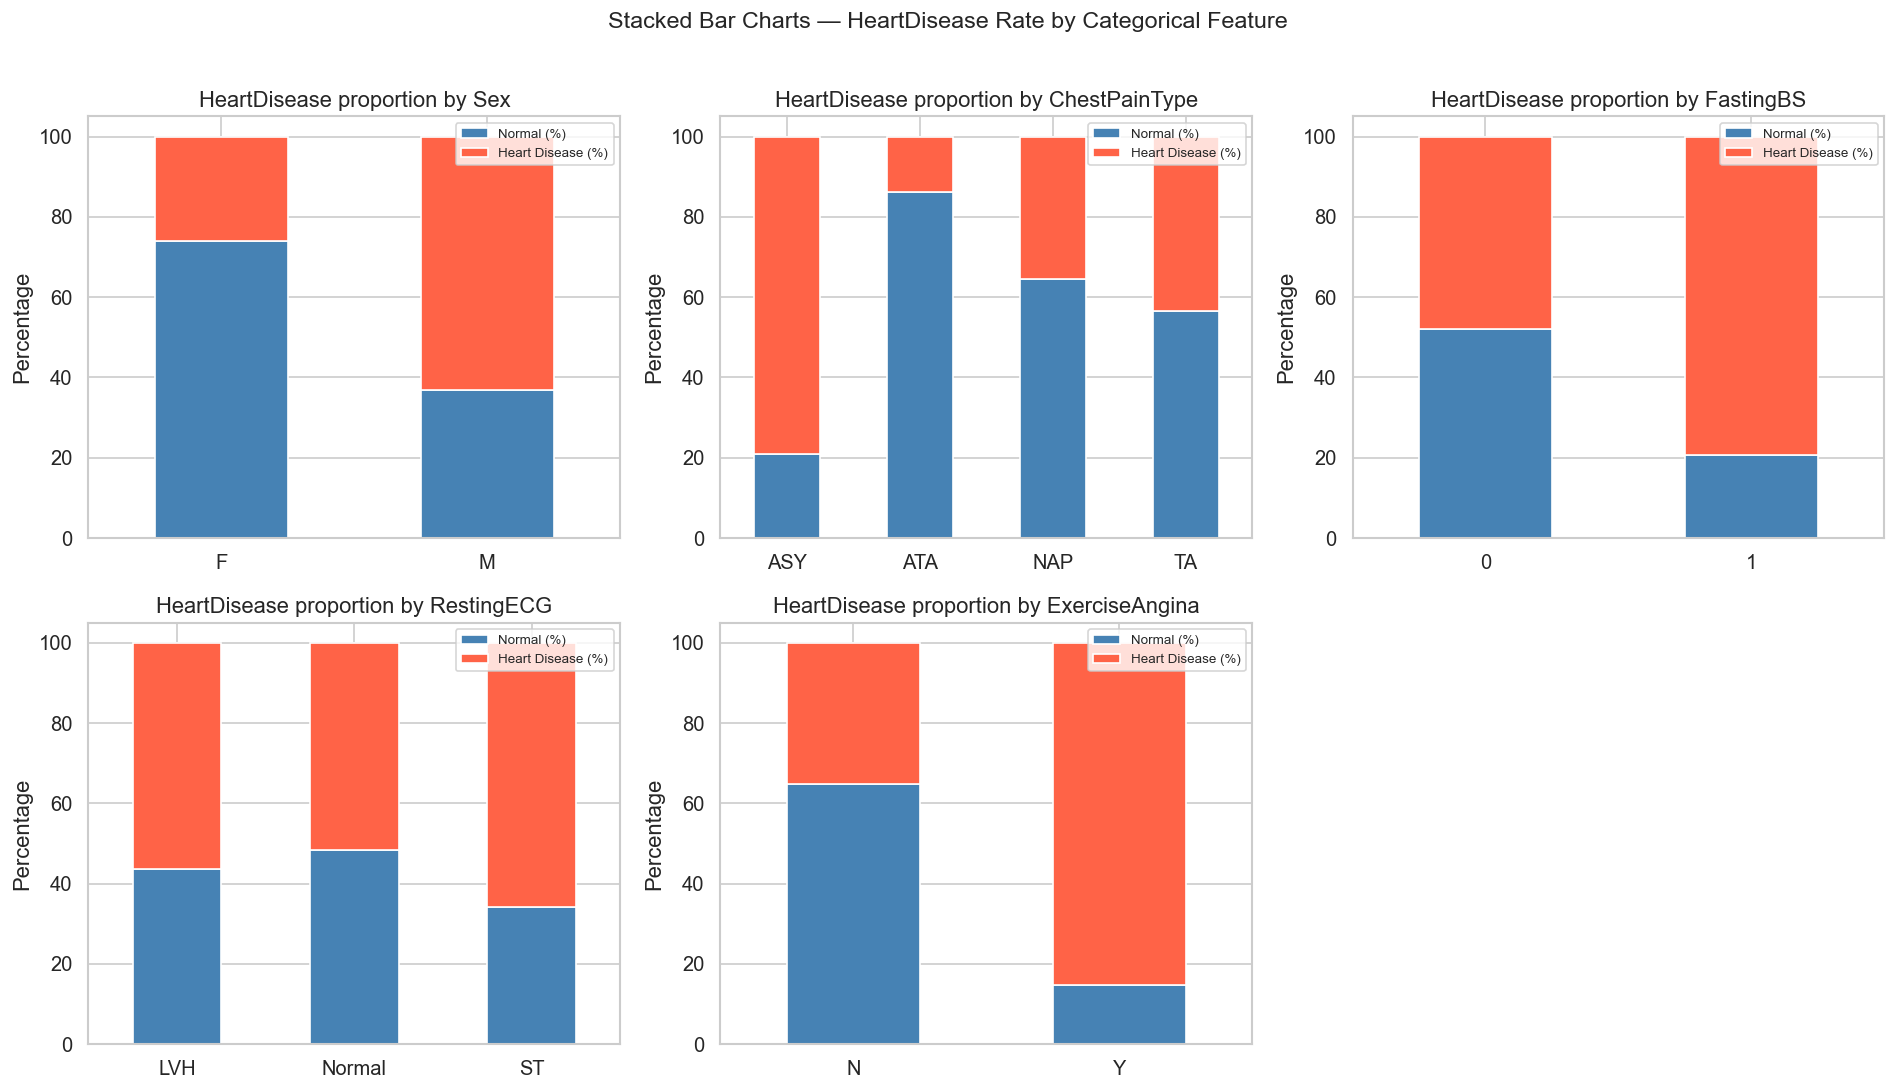

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df[target], normalize="index") * 100
    ct.columns = ["Normal (%)", "Heart Disease (%)"]
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["steelblue", "tomato"], edgecolor="white")
    axes[i].set_title(f"HeartDisease proportion by {col}")
    axes[i].set_ylabel("Percentage")
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis="x", rotation=0)

axes[-1].set_visible(False)
plt.suptitle("Stacked Bar Charts — HeartDisease Rate by Categorical Feature", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3c. Overall Feature Ranking Summary

In [34]:
rows = []
for _, r in num_pred_df.iterrows():
    rows.append({
        "Feature": r["Variable"],
        "Type": "Numerical",
        "Effect Size": r["|r|"],
        "Metric": "Point-Biserial |r|",
        "p-value": r["PB p-value"],
    })
for _, r in cat_pred_df.iterrows():
    rows.append({
        "Feature": r["Variable"],
        "Type": "Categorical",
        "Effect Size": r["Cramér's V"],
        "Metric": "Cramér's V",
        "p-value": r["p-value"],
    })

ranking_df = pd.DataFrame(rows).sort_values("Effect Size", ascending=False).reset_index(drop=True)
ranking_df.index += 1
ranking_df.index.name = "Rank"

ranking_df.style.format({
    "Effect Size": "{:.4f}",
    "p-value": "{:.2e}",
}).bar(subset=["Effect Size"], color="#2ca02c")

,Feature,Type,Effect Size,Metric,p-value
Rank,,,,,
1,ST_Slope,Categorical,0.6227,Cramér's V,5.17e-78
2,ChestPainType,Categorical,0.5404,Cramér's V,8.08e-58
3,ExerciseAngina,Categorical,0.4920,Cramér's V,2.91e-50
4,Oldpeak,Numerical,0.4040,Point-Biserial |r|,2.39e-37
5,MaxHR,Numerical,0.4004,Point-Biserial |r|,1.14e-36
6,Sex,Categorical,0.3028,Cramér's V,4.60e-20
7,Age,Numerical,0.2820,Point-Biserial |r|,3.01e-18
8,FastingBS,Categorical,0.2647,Cramér's V,1.06e-15
9,Cholesterol,Numerical,0.2327,Point-Biserial |r|,9.31e-13


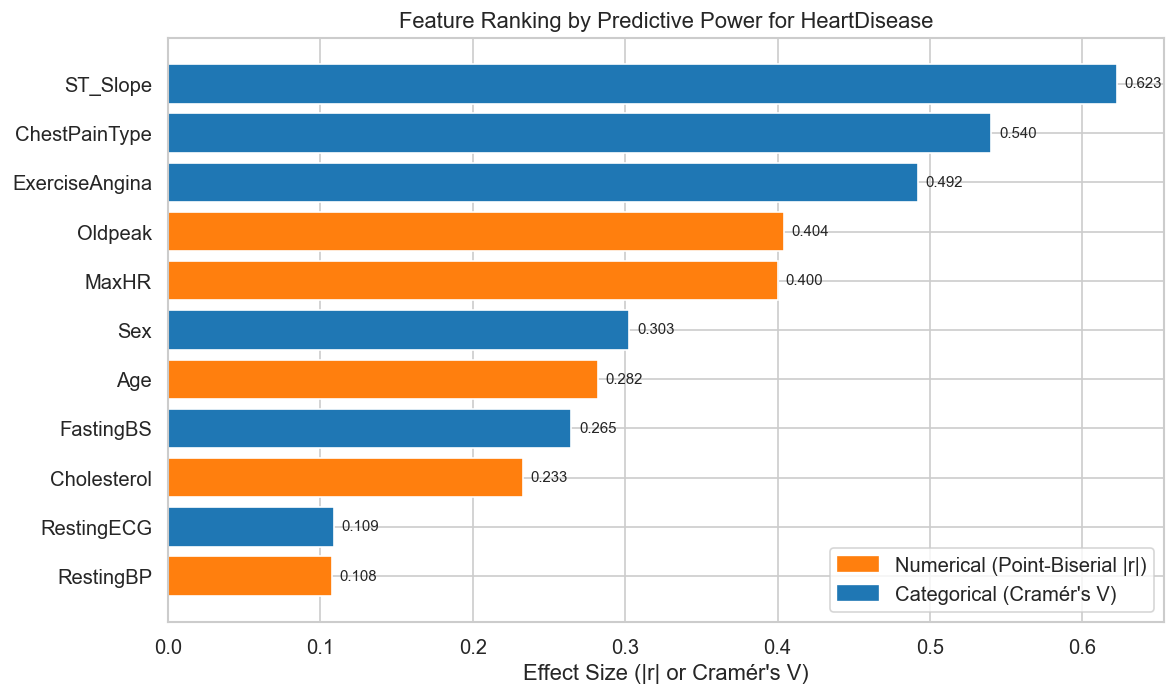

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#ff7f0e" if t == "Numerical" else "#1f77b4" for t in ranking_df["Type"]]
bars = ax.barh(ranking_df["Feature"], ranking_df["Effect Size"], color=colors, edgecolor="white")
ax.set_xlabel("Effect Size (|r| or Cramér's V)")
ax.set_title("Feature Ranking by Predictive Power for HeartDisease")
ax.invert_yaxis()

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="#ff7f0e", label="Numerical (Point-Biserial |r|)"),
    mpatches.Patch(color="#1f77b4", label="Categorical (Cramér's V)"),
], loc="lower right")

for bar, val in zip(bars, ranking_df["Effect Size"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

**Key findings from the predictive-power analysis:**

- **ST_Slope** and **ChestPainType** are expected to rank among the strongest categorical predictors (high Cramér's V), meaning the type of ST segment slope and the chest pain profile carry substantial discriminative information about heart disease.
- **ExerciseAngina** is also a strong binary categorical predictor — patients with exercise-induced angina are much more likely to have heart disease.
- Among numerical features, **Oldpeak** (ST depression) and **MaxHR** (maximum heart rate) show the largest absolute point-biserial correlations. Higher Oldpeak and lower MaxHR are both associated with heart disease.
- **Age** has a moderate positive association — older patients are somewhat more likely to have heart disease.
- **Cholesterol** and **RestingBP** tend to have the weakest associations, partly due to data quality issues (e.g., many zero cholesterol values likely represent missing data in the combined dataset).
- **FastingBS** and **RestingECG** tend to be weaker categorical predictors but still statistically significant.

All features tested show statistically significant associations with HeartDisease (p < 0.05), confirming that every variable in the dataset carries at least some predictive information for the classification task.